# Experiment I.1: Beta as continuous fitting parameter

This notebook is our first experiment, where we see if fitting the value of beta from the spacing ratio distribution restores the input value.

In practice, the fitted value is always slightly lower than the input value, due to finite N deviations from the Atas-Bogomolny-Giraud-Roux (ABGR) surmise.

In [1]:
# General imports
import numpy as np
import scipy
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Insert path of source folder
import sys
from pathlib import Path
root_dir = Path.cwd().parent
sys.path.insert(0, str(root_dir / "src"))

# And import the Package:
import beta_ensembles as be

# Default plotting style
plt.style.use(['seaborn-v0_8','./plot_style.mplstyle'])

# Default path to save figures
def savefig(fname):
    plt.savefig(str(Path.cwd().parent) + '\\figures\\' + fname + '.png')

# Part I: Fitted values of beta

We perform the experiment at N = 100 and N = 1000.

For N = 100, the notebook takes only a few minutes to run, generating all 5000 spectra and performing all the fits. In the latter case of N = 1000 the notebook takes approximately 40 minutes to run (on a fairly old but decent laptop).

In [2]:
beta_vals = np.arange(0.5,8.5,0.5)
n_beta = len(beta_vals)

N = 100
# N = 1000
n_spectra = 5000

# We add N dependence to RNG so the two samples are completely uncorrelated
rng = np.random.default_rng(seed=sum(b'Shiratama anmitsu')+N)

all_spectra = np.zeros((n_beta,n_spectra,N))

for i, beta in enumerate(tqdm(beta_vals,desc='Total progress',position=1)):
    all_spectra[i] = be.gaussian.spectra(beta,N,n_spectra,rng,verbose=True)

all_spectra_u = np.array([be.gaussian.unfold(all_spectra[i]) for i in range(n_beta)])

Total progress:   0%|          | 0/16 [00:00<?, ?it/s]

Generating GBE spectra: 100%|████████████████████████████████████████████████████| 5000/5000 [00:03<00:00, 1394.67it/s]


We will work with the reduced spacing ratios in this experiment. Let's plot some histograms to visualize the different values of beta:

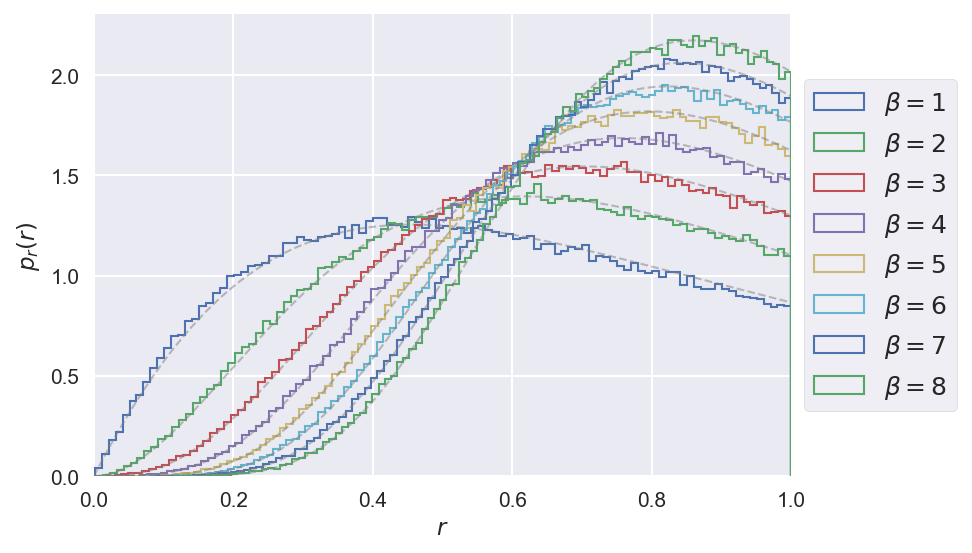

In [3]:
cutoff = round(N/10)

all_ratios = be.ratios(all_spectra[:,:,cutoff:-cutoff])
all_ratios_u = be.ratios(all_spectra_u[:,:,cutoff:-cutoff])

for i, ratios in enumerate(all_ratios):
    if (i + 1) % 2 == 0:
        be.plot.hist_r(ratios,histtype='step',lw=1,label=rf'$\beta = {beta_vals[i]:.0f}$');
        be.plot.pdf_r(beta_vals[i],label=None,c='gray',ls='--',lw=1,alpha=0.5)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5));

To get some idea of what is the range of fitted values of beta, we fit it to subgroups of 500 spectra each, and see how the fitted values differ from the input parameters. We also do a fit to the full sample of 5000 spectra.

In all cases we fit both the ratios computed from the original spectra, and the ratios of the unfolded spectra. The difference will be minimal, as we will see below.

We also compute the mean spacing ratios, a quantity that does not require fitting.

This takes a little while to run since it performs 2 * (n_groups + 1) * n_beta fits in total, with n_spectra * (N-2) data points every time.

In [4]:
# Set size of subgroup. The product of the two should equal n_spectra:
n_sample = 500
n_groups = 10

# Compute the expected mean ratio from the analytic formula
mean_ratios_exp = [be.statistics.mean_ratio(beta) for beta in beta_vals]

# Array to contain the fitted values of beta for the subgroups.
# The first 2 is there because we fit separately the original and unfolded spectra
beta_vals_fit = np.zeros((2,n_beta,n_groups))
# Array to contain the fitted values of beta for the large samples
beta_vals_fit_all = np.zeros((2,n_beta))

# Arrays to contain the measured mean ratios
mean_ratios = np.zeros((2,n_beta,n_groups))
mean_ratios_all = np.zeros((2,n_beta))

# Loop to fit all the spectra at the different values of beta
for i, beta in enumerate(tqdm(beta_vals)):
    for j in range(n_groups):
        # Without unfolding
        ratios = all_ratios[i][n_sample * j:n_sample * (j+1)]
        beta_vals_fit[0,i,j] = be.fit_ratios(ratios)
        mean_ratios[0,i,j] = ratios.mean()
        # With unfolding
        ratios = all_ratios_u[i][n_sample * j:n_sample * (j+1)]
        beta_vals_fit[1,i,j] = be.fit_ratios(ratios)
        mean_ratios[1,i,j] = ratios.mean()
    
    beta_vals_fit_all[0,i] = be.fit_ratios(all_ratios[i])
    mean_ratios_all[0,i] = all_ratios[i].mean()

    beta_vals_fit_all[1,i] = be.fit_ratios(all_ratios_u[i])
    mean_ratios_all[1,i] = all_ratios[i].mean()

  0%|          | 0/16 [00:00<?, ?it/s]

Plot the results for the fitted values of beta and compare with the input values.

The right panel is in figure 6.1 of our note.

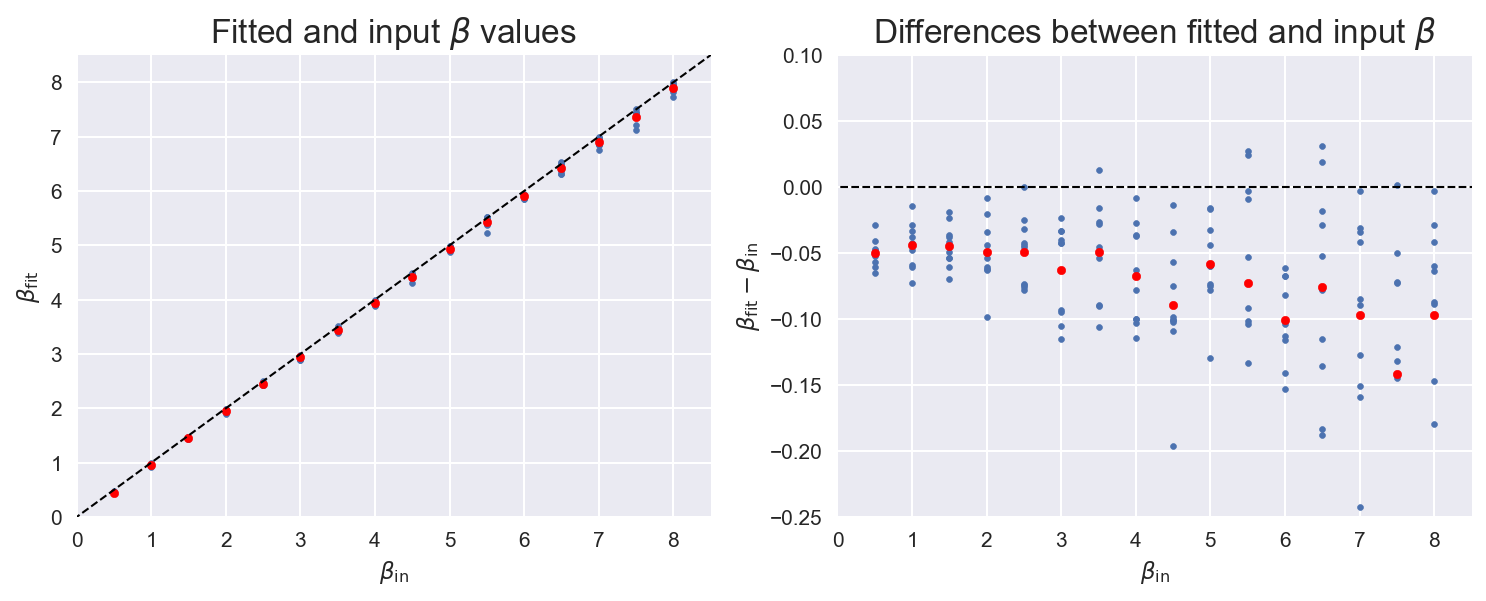

In [5]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))

plt.subplot(1,2,1)

for i in range(n_groups):
    plt.scatter(beta_vals,beta_vals_fit[0,:,i],c='#4C72B0',s=8)
    
plt.scatter(beta_vals,beta_vals_fit_all[0,:],c='r',s=16)

plt.title(r'Fitted and input $\beta$ values')
plt.xlabel(r'$\beta_\text{in}$')
plt.ylabel(r'$\beta_\text{fit}$')


plt.plot([-1,12],[-1,12],c='k',lw=1,ls='--')
plt.xlim(0,8.5)
plt.ylim(0,8.5);

plt.subplot(1,2,2)

for i in range(n_groups):
    plt.scatter(beta_vals,(beta_vals_fit[0,:,i]-beta_vals),c='#4C72B0',s=8)

plt.scatter(beta_vals,beta_vals_fit_all[0,:]-beta_vals,c='r',s=16)

plt.title(r'Differences between fitted and input $\beta$')
plt.xlabel(r'$\beta_\text{in}$')
plt.ylabel(r'$\beta_{\text{fit}} - \beta_{\text{in}}$')

plt.hlines(0,-1,12,colors='k',lw=1,ls='--')
plt.xlim(0,8.5)
plt.ylim(-0.25,0.1);

# Save only the right plot
bbox = ax2.get_tightbbox(fig.canvas.get_renderer())
fname = str(Path.cwd().parent) + f'\\figures\\1a_{N}_temp.png'
# plt.savefig(fname,bbox_inches=bbox.transformed(fig.dpi_scale_trans.inverted()))

Likewise, plot the results for the measured values of the mean spacing ratio and compare with the expected result for the input value of beta.

The right panel is in figure 6.1 of our note.

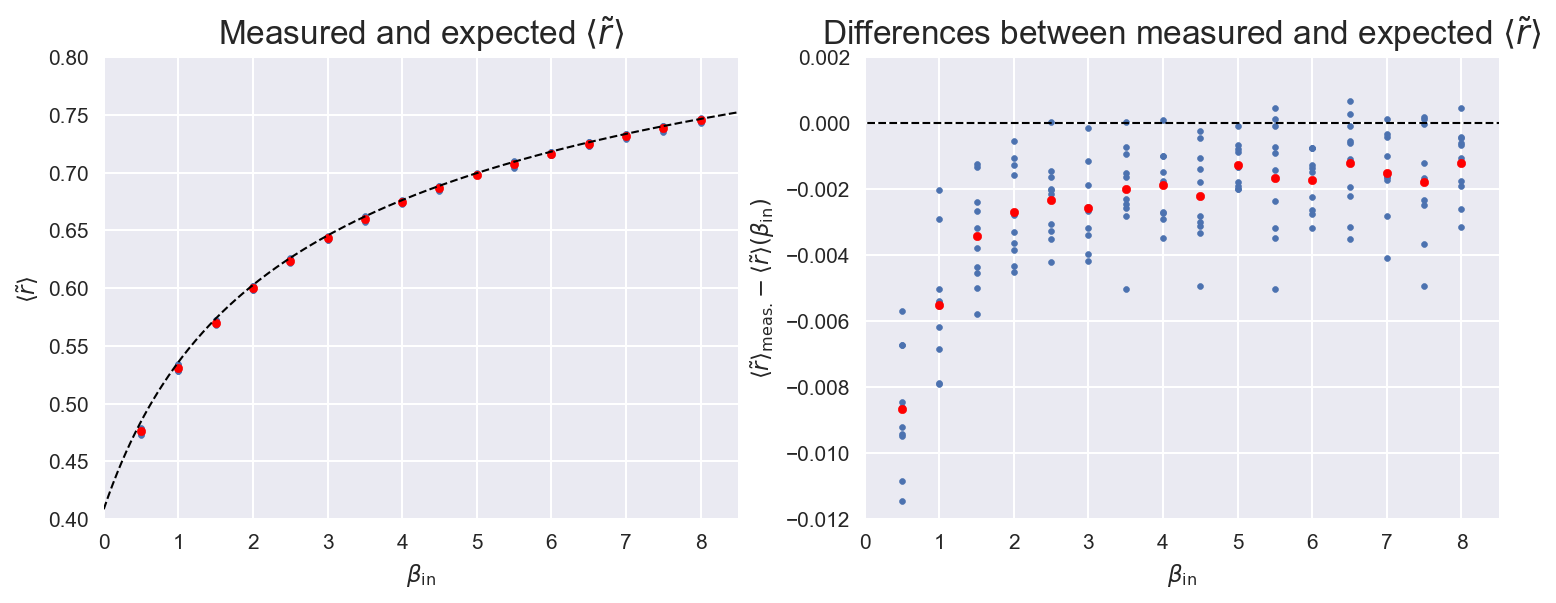

In [6]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))

plt.subplot(1,2,1)

for i in range(n_groups):
    plt.scatter(beta_vals,mean_ratios[0,:,i],c='#4C72B0',s=8)

plt.scatter(beta_vals,mean_ratios_all[0,:],c='r',s=16)

plt.title(r'Measured and expected $\langle {\tilde r}\rangle$')
plt.xlabel(r'$\beta_\text{in}$')
plt.ylabel(r'$\langle{\tilde r}\rangle$')

bb = np.linspace(0,12,400)
rr = [be.statistics.mean_ratio(b) for b in bb]
plt.plot(bb,rr,c='k',lw=1,ls='--')

plt.xlim(0,8.5)
plt.ylim(0.4,0.8)

plt.subplot(1,2,2)

for i in range(n_groups):
    plt.scatter(beta_vals,mean_ratios[0,:,i]-mean_ratios_exp,c='#4C72B0',s=8)

plt.scatter(beta_vals,mean_ratios_all[0,:]-mean_ratios_exp,c='r',s=16)

plt.title(r'Differences between measured and expected $\langle {\tilde r}\rangle $')
plt.xlabel(r'$\beta_\text{in}$')
plt.ylabel(r'$\langle{\tilde r}\rangle_{\text{meas.}} - \langle \tilde r\rangle(\beta_\text{in})$')
plt.hlines(0,-1,12,colors='k',lw=1,ls='--')
plt.xlim(0,8.5)
plt.ylim(-0.012,0.002);

# Code for saving only the right plot
bbox = ax2.get_tightbbox(fig.canvas.get_renderer())
fname = str(Path.cwd().parent) + f'\\figures\\1b_{N}_temp.png'
# plt.savefig(fname,bbox_inches=bbox.transformed(fig.dpi_scale_trans.inverted()))

We can see that the effect of the unfolding is almost negligible, by comparing the difference in the fitted values of beta:

In [7]:
print('The maximum of the (abs) differnce beta_fit between the original and unfolded spectra is (small subgroups):')
print(f'{np.abs(beta_vals_fit[0,:]-beta_vals_fit[1,:]).max():.6f}')
print('The maximum of the (abs) differnce beta_fit between the original and unfolded spectra is (whole sample):')
print(f'{np.abs(beta_vals_fit_all[0,:]-beta_vals_fit_all[1,:]).max():.6f}')

The maximum of the (abs) differnce beta_fit between the original and unfolded spectra is (small subgroups):
0.005566
The maximum of the (abs) differnce beta_fit between the original and unfolded spectra is (whole sample):
0.004492


Lastly, we compare here the residual function suggested by ABGR, being the difference between the surmise and the measured distribution at finite N, to the difference between the PDFs of two values of beta. The two functions are qualitatively the same, explaining why the results are always pushed to lower beta.

Note that here we do not refer to the data.

A more sophisticated fit could use this residual function with extra parameter C_N. Then we expect the fitted values of beta to be nearer to the input values. This is left as an exercise to the reader!

The figure produced here is figure 6.2 in our note.

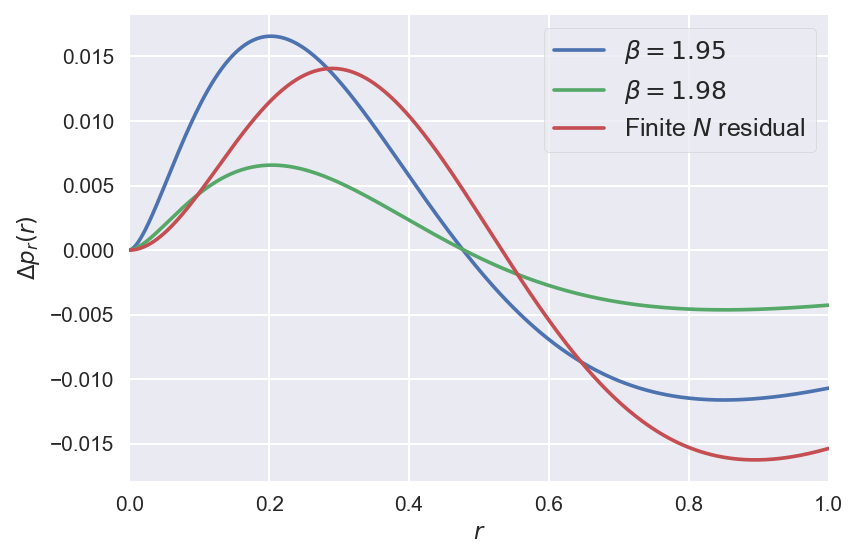

In [8]:
fig, ax = plt.subplots(figsize=(6,4))

r_grid = np.linspace(0.00001,1,400)

beta = 2
beta_1 = beta-0.05
beta_2 = beta-0.02
pdf_0 = be.statistics.pdf_r(beta,r_grid)
pdf_1 = be.statistics.pdf_r(beta_1,r_grid)
pdf_2 = be.statistics.pdf_r(beta_2,r_grid)

pdf_res = be.statistics.pdf_r_residual(beta,0.6,r_grid)

plt.plot(r_grid,pdf_1-pdf_0,label=rf'$\beta={beta_1:.2f}$')
plt.plot(r_grid,pdf_2-pdf_0,label=rf'$\beta={beta_2:.2f}$')
plt.plot(r_grid,pdf_res,label=r'Finite $N$ residual')

plt.xlabel(r'$r$')
plt.ylabel(r'$\Delta p_r(r)$')

plt.xlim(0,1)

plt.legend()
plt.tight_layout()

# savefig('1c_temp.png')